In [35]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor

# Load data
file_path_train = 'data/train.csv'
file_path_test = 'data/test.csv'
train_data = pd.read_csv(file_path_train, index_col=None)
test_data = pd.read_csv(file_path_test, index_col=None)

# Select features
features = ['LotArea', 'YearBuilt', '1stFlrSF', '2ndFlrSF', 'FullBath', 'BedroomAbvGr', 'TotRmsAbvGrd']
X = train_data[features]
y = train_data.SalePrice

print("Data loaded successfully!")




Data loaded successfully!


In [60]:
X.corr()

,LotArea,YearBuilt,1stFlrSF,2ndFlrSF,FullBath,BedroomAbvGr,TotRmsAbvGrd
LotArea,1.000000,0.014228,0.299475,0.050986,0.126031,0.119690,0.190015
YearBuilt,0.014228,1.000000,0.281986,0.010308,0.468271,-0.070651,0.095589
1stFlrSF,0.299475,0.281986,1.000000,-0.202646,0.380637,0.127401,0.409516
2ndFlrSF,0.050986,0.010308,-0.202646,1.000000,0.421378,0.502901,0.616423
FullBath,0.126031,0.468271,0.380637,0.421378,1.000000,0.363252,0.554784
BedroomAbvGr,0.119690,-0.070651,0.127401,0.502901,0.363252,1.000000,0.676620
TotRmsAbvGrd,0.190015,0.095589,0.409516,0.616423,0.554784,0.676620,1.000000


In [36]:
#Define Model
train_model = DecisionTreeRegressor(random_state=1)




In [37]:
#Fit Model
train_model.fit(X,y)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [38]:
print("Making predictions for the following 5 houses")  
print(X.head())
print("The predictions are: ")
print(train_model.predict(X.head()))

Making predictions for the following 5 houses
   LotArea  YearBuilt  1stFlrSF  2ndFlrSF  FullBath  BedroomAbvGr  \
0     8450       2003       856       854         2             3   
1     9600       1976      1262         0         2             3   
2    11250       2001       920       866         2             3   
3     9550       1915       961       756         1             3   
4    14260       2000      1145      1053         2             4   

   TotRmsAbvGrd  
0             8  
1             6  
2             6  
3             7  
4             9  
The predictions are: 
[208500. 181500. 223500. 140000. 250000.]


In [39]:
from sklearn.metrics import mean_absolute_error

predicted_home_prices = train_model.predict(X)
mean_absolute_error(y, predicted_home_prices)

#this works for the training data, but could be inaccurate when it comes to 


62.35433789954339

In [40]:
from sklearn.model_selection import train_test_split

#split the data up into training and validation data, for both features and target
# the split is based on a random number generator. supplying a numeric value to the 
# random_state argument guarantees we get the same split every time we run this script

train_X, val_X, train_y, val_y, = train_test_split(X, y, random_state =1)

#define the model
train_model = DecisionTreeRegressor(random_state=1)

train_model.fit(train_X, train_y)

#get predicted prices on validation data
val_predictions = train_model.predict(val_X)
print(mean_absolute_error(val_y, val_predictions))



29652.931506849316


In [54]:
%pip install matplotlib ipympl

   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   -------------- ------------------------- 0.8/2.2 MB 3.0 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 6.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: C:\Users\jorda\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [56]:
import matplotlib.pyplot as plt

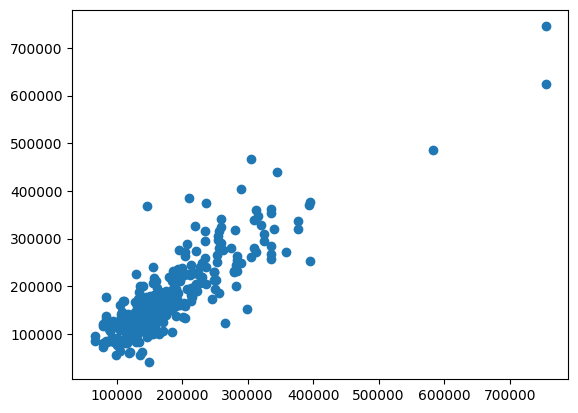

In [58]:
plt.scatter(val_predictions, val_y)

In [53]:
def get_mae(max_leaf_nodes, train_X, val_X, train_y, val_y):
    model = DecisionTreeRegressor(max_leaf_nodes=max_leaf_nodes, random_state=1)
    model.fit(train_X, train_y)
    preds_val = model.predict(val_X)
    mae = mean_absolute_error(val_y, preds_val)
    return mae


In [42]:
#compare MAe with differing values of max_leaf_nodes

for max_leaf_nodes in [5, 50, 500, 5000]:
    my_mae = get_mae(max_leaf_nodes, train_X, val_X, train_y, val_y)
    print("Max leaf nodes: %d \t\t Mean Absolute Error: %d" %(max_leaf_nodes,my_mae))


Max leaf nodes: 5 		 Mean Absolute Error: 35044
Max leaf nodes: 50 		 Mean Absolute Error: 27405
Max leaf nodes: 500 		 Mean Absolute Error: 28357
Max leaf nodes: 5000 		 Mean Absolute Error: 28942


In [43]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
train_X_imp = imputer.fit_transform(train_X)
val_X_imp = imputer.transform(val_X)


In [52]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

forest_model = RandomForestRegressor(random_state=1)
forest_model.fit(train_X, train_y)
melb_preds = forest_model.predict(val_X_imp)
print(mean_absolute_error(val_y, melb_preds))

21857.15912981083


C:\Users\jorda\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [45]:
test_X = test_data[features]
test_X_imp = imputer.transform(test_X)
test_preds = forest_model.predict(test_X_imp)

C:\Users\jorda\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [46]:
output = pd.DataFrame({'Id' : test_data['Id'], 'SalePrice' : test_preds})
output.to_csv('submission.csv', index = False)